In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5          # duration: 11.5-15.5 minutes
    X[:, 0] = X[:, 0] * (285 - 150) + 150  # temperature: 150-285 Celsius
    Y = np.zeros(len(X))

    i = 0
    for t, d in X:
        y = -3 / (260 - 175) * t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d <= y):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1, 1))

X, Y = load_coffee_data()

In [3]:
print(f'{X.shape},{Y.shape}')

(200, 2),(200, 1)


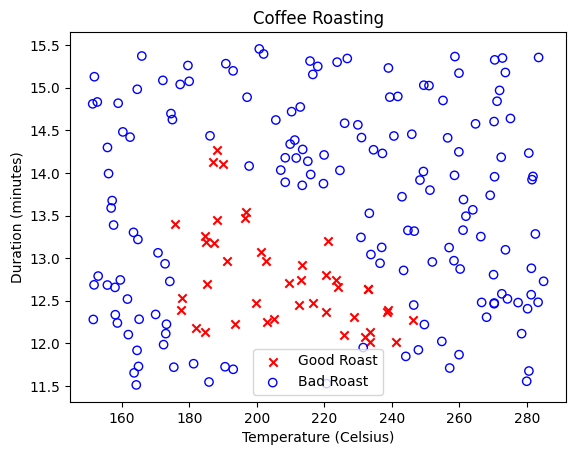

In [4]:
def plot_data(X, Y):
    pos = Y[:, 0] == 1   # good roast
    neg = Y[:, 0] == 0   # bad roast

    plt.scatter(X[pos, 0], X[pos, 1], marker='x', c='red', label='Good Roast')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', facecolors='none', edgecolors='blue', label='Bad Roast')

    plt.title('Coffee Roasting')
    plt.xlabel('Temperature (Celsius)')
    plt.ylabel('Duration (minutes)')
    plt.legend()
    plt.show()

plot_data(X, Y)

In [5]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


In [6]:
Xt=np.tile(Xn,(1000,1))
Yt=np.tile(Y,(1000,1))
print(f"{Xt.shape},{Yt.shape}")

(200000, 2),(200000, 1)


In [18]:
tf.random.set_seed(123)
model=Sequential([
       tf.keras.Input(shape=(2,)),
       Dense(units=10,activation='relu',name='L1'),
       Dense(units=1,activation='sigmoid',name='L2'),
])

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ L1 (Dense)                           │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ L2 (Dense)                           │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 10):
 [[ 0.03509063 -0.18881637  0.30997878  0.43181103 -0.17328286 -0.60140365
   0.4734487   0.3220721   0.4253109   0.21457821]
 [ 0.6089243   0.6801427   0.29285318 -0.5799482  -0.29177082  0.70049864
  -0.40183496  0.00711119  0.65950674 -0.16458648]] 
b1(10,): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
W2(10, 1):
 [[ 0.35514408]
 [-0.3618756 ]
 [ 0.02655607]
 [-0.43740815]
 [-0.42477643]
 [-0.11127299]
 [ 0.66105264]
 [-0.2610893 ]
 [-0.16558373]
 [-0.42009807]] 
b2(1,): [0.]


In [21]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
)


In [22]:
model.fit(
    Xt,Yt,
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 654us/step - loss: 0.0524
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 663us/step - loss: 0.0120
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 654us/step - loss: 0.0053
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 652us/step - loss: 0.0027
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 659us/step - loss: 0.0019
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 659us/step - loss: 7.7320e-04
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 664us/step - loss: 0.0013
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 642us/step - loss: 0.0013    
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 647us/step - loss: 1.6774e-04
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 654us/step - loss: 7.1781e-04


In [23]:
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[ 0.13577653  3.8823342   4.0858502   1.1412503  -5.230923   -5.9123526
   1.9577008   3.9963348   4.4797277   3.7310517 ]
 [ 0.29856324  2.7581494   3.6920903  -7.1259546   0.34873423  2.830435
   4.3096204   3.3803296   4.519715    3.178542  ]] 
b1: [-0.2908202  1.2024714  0.9932378 -6.4850044 -4.7288256 -2.1261902
  8.073962   1.0827962  1.8736802  1.0037454]
W2:
 [[  0.06952044]
 [-12.178425  ]
 [-20.10247   ]
 [-16.47929   ]
 [-33.37027   ]
 [-10.875049  ]
 [ 13.42505   ]
 [-21.852861  ]
 [-21.677269  ]
 [-23.419605  ]] 
b2: [6.739711]


In [24]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
predictions = 
 [[1.]
 [0.]]


In [25]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


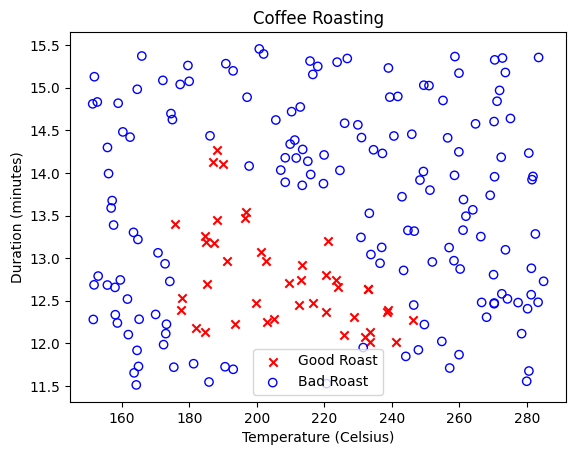

In [26]:
plot_data(X,Y)

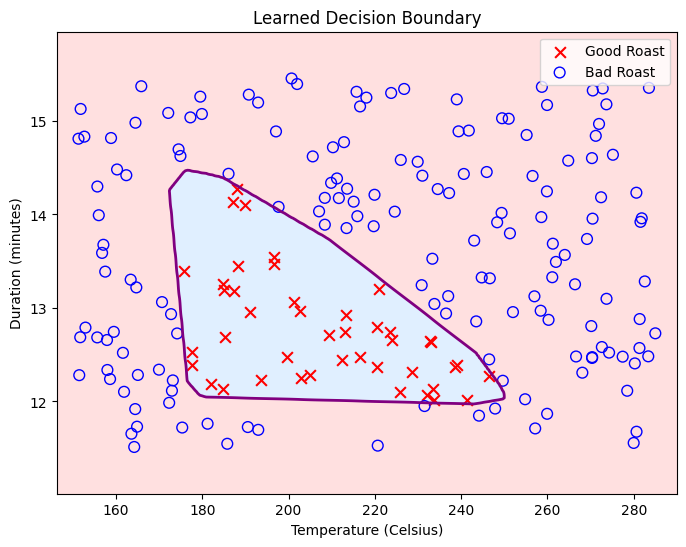

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, norm_l, X, Y):
    # Create a grid covering the range of your original data
    temp_min, temp_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    dur_min, dur_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(temp_min, temp_max, 300),
        np.linspace(dur_min, dur_max, 300)
    )

    # Flatten grid into (N, 2) points, normalize, predict
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_norm = norm_l(grid_points)
    preds = model.predict(grid_points_norm, verbose=0)
    preds = preds.reshape(xx.shape)

    # Plot filled contour for the decision regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=['#FFCCCC', '#CCE5FF'], alpha=0.6)
    plt.contour(xx, yy, preds, levels=[0.5], colors='purple', linewidths=2)  # the boundary line itself

    # Overlay your original data points
    good = Y[:, 0] == 1
    bad = Y[:, 0] == 0
    plt.scatter(X[good, 0], X[good, 1], c='red', marker='x', label='Good Roast', s=60)
    plt.scatter(X[bad, 0], X[bad, 1], facecolors='none', edgecolors='blue', label='Bad Roast', s=60)

    plt.xlabel('Temperature (Celsius)')
    plt.ylabel('Duration (minutes)')
    plt.title('Learned Decision Boundary')
    plt.legend()
    plt.show()

plot_decision_boundary(model, norm_l, X, Y)